In [6]:
from rich.console import Console
from rich.markdown import Markdown

console = Console()
md = Markdown("""
# Idea Summary - VIX based QQQ strengthen

**How I get my idea**

This strategy serves as a practice of a simple idea: \n
For QQQ, if VIX>a, buy in the close, if VIX<b, leverage in the close.
Then for a period of 10 years what's the performance \n
Data used: Yahoo finance
""")
console.print(md)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                     Idea Summary - VIX based QQQ strengthen                                     ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

How I get my idea                                                                                                  

This strategy serves as a practice of a simple idea:                                                               

For QQQ, if VIX>a, buy in the close, if VIX<b, sell in the close. Then for a period of 10 years what's the         
performance                                                                                                        

Data used: Yahoo finance

Fetching data from 2016-10-11 to 2026-10-09...

=== Performance Report (10 Years) ===
Strategy Thresholds: Buy VIX>20, Lev VIX<15
Strategy CAGR: 28.46%
Benchmark (QQQ) CAGR: 21.15%
Strategy Sharpe Ratio: 1.12
Benchmark (QQQ) Sharpe Ratio: 0.97
Strategy Max Drawdown: -35.12%
Benchmark (QQQ) Max Drawdown: -35.12%


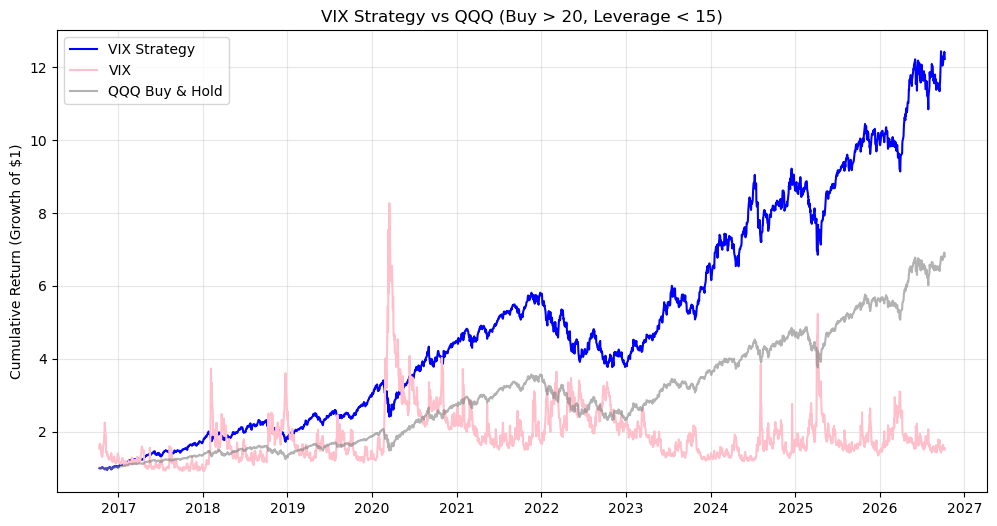

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


#Parameters area
A_BUY_THRESHOLD = 20  
B_LEV_THRESHOLD = 15 
long_position = 1
lev_position = 1.9
normal_pos = 1

START_DATE = (datetime.now() - timedelta(days=365*10)).strftime('%Y-%m-%d') # Last 10 years
END_DATE = datetime.now().strftime('%Y-%m-%d')

tickers = ['QQQ', '^VIX']




# ==========================================
# 1. PARAMETERS & DATA FETCHING
# ==========================================
# Define strategy parameters


print(f"Fetching data from {START_DATE} to {END_DATE}...")

# Download data for QQQ (ETF) and ^VIX (Volatility Index)

data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)['Close']

# Clean data and rename columns for easier access
df = data.copy()
df.columns = ['QQQ', 'VIX']
df = df.dropna()

# ==========================================
# 2. STRATEGY LOGIC
# ==========================================
# Calculate daily returns for QQQ (used for performance calculation)
df['QQQ_Ret'] = df['QQQ'].pct_change()

# Initialize 'Position' column: 1 = Long, 0 = Cash
# We use a loop here because the state depends on the previous day's holding status
df['Position'] = 0

# Convert columns to numpy arrays for faster iteration (optimizing speed)
vix_values = df['VIX'].values
positions = np.zeros(len(df))


for i in range(len(df)):
    current_pos = normal_pos 
    # "If VIX > a, buy in the close"
    if vix_values[i] > A_BUY_THRESHOLD:
        current_pos = long_position
    
    # "If VIX < b, lev in the close"
    elif vix_values[i] < B_LEV_THRESHOLD:
        current_pos = lev_position
        
    # Else: Hold previous position (implied by not changing current_pos)
    positions[i] = current_pos

df['Position'] = positions

# ==========================================
# 3. BACKTEST PERFORMANCE
# ==========================================
# Shift position by 1 day to avoid look-ahead bias.
# Logic: We see VIX at Close(t), make decision, and buy at Close(t). 
# Our exposure begins for the return from Close(t) to Close(t+1).
df['Strategy_Ret'] = df['Position'].shift(1) * df['QQQ_Ret']

# Cumulative Returns
df['QQQ_Cum_Ret'] = (1 + df['QQQ_Ret']).cumprod()
df['Strategy_Cum_Ret'] = (1 + df['Strategy_Ret']).cumprod()

# ==========================================
# 4. METRICS CALCULATION
# ==========================================
# Annualized Return (CAGR)
total_days = (df.index[-1] - df.index[0]).days
cagr_QQQ = (df['QQQ_Cum_Ret'].iloc[-1])**(365/total_days) - 1
cagr_strat = (df['Strategy_Cum_Ret'].iloc[-1])**(365/total_days) - 1

# Sharpe Ratio (assuming risk-free rate = 0 for simplicity)
sharpe_QQQ = (df['QQQ_Ret'].mean() / df['QQQ_Ret'].std()) * np.sqrt(252)
sharpe_strat = (df['Strategy_Ret'].mean() / df['Strategy_Ret'].std()) * np.sqrt(252)

# Max Drawdown
rolling_max_strat = df['Strategy_Cum_Ret'].cummax()
daily_drawdown_strat = df['Strategy_Cum_Ret'] / rolling_max_strat - 1.0
max_drawdown_strat = daily_drawdown_strat.min()

# Max Drawdown_QQQ
rolling_max_QQQ = df['QQQ_Cum_Ret'].cummax()
daily_drawdown_QQQ = df['QQQ_Cum_Ret'] / rolling_max_QQQ - 1.0
max_drawdown_QQQ = daily_drawdown_QQQ.min()

print(f"\n=== Performance Report (10 Years) ===")
print(f"Strategy Thresholds: Buy VIX>{A_BUY_THRESHOLD}, Lev VIX<{B_LEV_THRESHOLD}")
print(f"Strategy CAGR: {cagr_strat:.2%}")
print(f"Benchmark (QQQ) CAGR: {cagr_QQQ:.2%}")
print(f"Strategy Sharpe Ratio: {sharpe_strat:.2f}")
print(f"Benchmark (QQQ) Sharpe Ratio: {sharpe_QQQ:.2f}")
print(f"Strategy Max Drawdown: {max_drawdown_strat:.2%}")
print(f"Benchmark (QQQ) Max Drawdown: {max_drawdown_QQQ:.2%}")

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Strategy_Cum_Ret'], label='VIX Strategy', color='blue')
plt.plot(df.index, df['VIX']/10, label='VIX', color='pink')
plt.plot(df.index, df['QQQ_Cum_Ret'], label='QQQ Buy & Hold', color='gray', alpha=0.6)
plt.title(f'VIX Strategy vs QQQ (Buy > {A_BUY_THRESHOLD}, Leverage < {B_LEV_THRESHOLD})')
plt.ylabel('Cumulative Return (Growth of $1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Loaded 2,513 observations: 2016-10-10 to 2026-10-08

FULL PERIOD PERFORMANCE
                  VIX Strategy (Net) QQQ Buy & Hold BIL Cash Proxy
Total Return                 812.30%        571.01%         25.60%
CAGR                          24.76%         20.98%          2.31%
Annual Volatility             31.36%         22.57%          0.25%
Sharpe                          0.79           0.86           0.00
Sortino                         1.13           1.22            N/A
Max Drawdown                 -50.12%        -35.12%         -0.21%
Calmar                          0.49           0.60          11.07
QQQ Beta                        1.37           1.00          -0.00

RECENT THREE-YEAR PERFORMANCE
                  VIX Strategy (Net) QQQ Buy & Hold BIL Cash Proxy
Total Return                 153.71%        107.42%         13.94%
CAGR                          36.42%         27.55%          4.45%
Annual Volatility             26.49%         20.43%          0.23%
Sharpe               

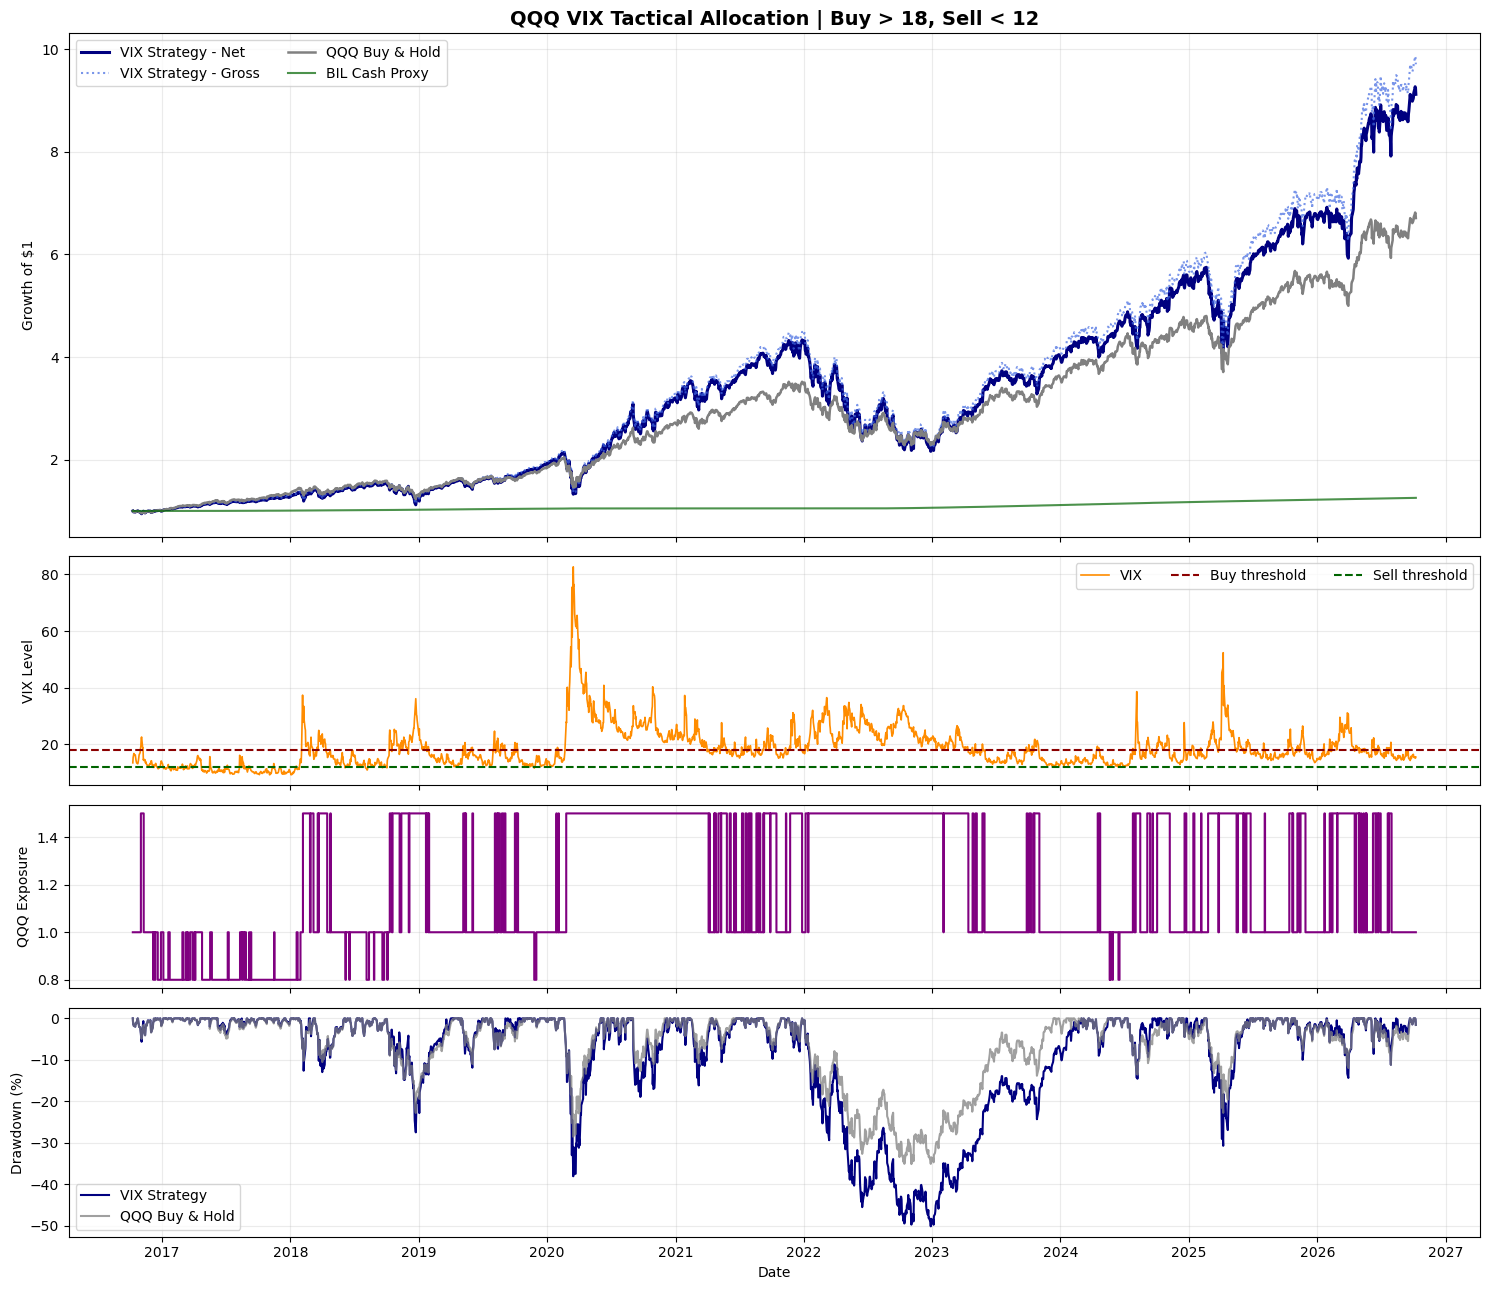


Research outputs saved to: C:\Users\xchen\Downloads\QQQ_VIX_Research


In [33]:

"""
QQQ / VIX Tactical Allocation Backtest
======================================

Hypothesis:
    Buy QQQ when VIX > upper threshold.
    Exit QQQ when VIX < lower threshold.
    Otherwise, retain previous allocation.

Execution:
    Observe completed VIX value after session t.
    Rebalance at QQQ's next session close (t+1).
    New exposure earns returns from close t+1 onward.

Benchmark:
    QQQ buy and hold.

Cash proxy:
    BIL (1-3 month US Treasury ETF).

Important:
    Research backtest, not an executable trading system.
    Yahoo Finance data and hypothetical fills require
    independent validation before live trading.
"""

from dataclasses import dataclass, replace
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf


# ============================================================
# 1. CONFIGURATION
# ============================================================

@dataclass(frozen=True)
class Config:
    years: int = 10

    # VIX signal thresholds
    buy_vix: float = 18.0
    sell_vix: float = 12.0

    # QQQ portfolio exposure
    high_vix_exposure: float = 1.5
    low_vix_exposure: float = 0.8
    initial_exposure: float = 1

    # Hypothetical costs per traded dollar
    commission_bps: float = 1.0
    slippage_bps: float = 4.0

    # Illustrative financing APR when exposure > 100%
    financing_apr: float = 0.06

    trading_days: int = 252
    output_dir: str = "QQQ_VIX_Research"


CFG = Config()


# ============================================================
# 2. DATA COLLECTION & VALIDATION
# ============================================================

def download_data(cfg: Config) -> pd.DataFrame:
    """
    Retrieve adjusted historical daily prices.

    Excludes today's session to avoid using an
    incomplete VIX or QQQ daily bar.
    """
    today_et = datetime.now(
        ZoneInfo("America/New_York")
    ).date()

    start = (
        pd.Timestamp(today_et)
        - pd.DateOffset(years=cfg.years)
    ).date()

    tickers = ["QQQ", "^VIX", "BIL"]

    print(
        f"Downloading {cfg.years} years of daily data: "
        f"{start} to before {today_et}"
    )

    raw = yf.download(
        tickers=tickers,
        start=start.isoformat(),
        end=today_et.isoformat(),
        interval="1d",
        auto_adjust=True,
        group_by="column",
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise RuntimeError(
            "No market data returned. Check Yahoo Finance."
        )

    if not isinstance(raw.columns, pd.MultiIndex):
        raise RuntimeError(
            "Unexpected Yahoo Finance column format."
        )

    close = raw["Close"].copy()

    missing = [
        ticker for ticker in tickers
        if ticker not in close.columns
    ]

    if missing:
        raise RuntimeError(
            f"Missing tickers in downloaded data: {missing}"
        )

    prices = close[tickers].rename(
        columns={"^VIX": "VIX"}
    )

    prices = prices.apply(
        pd.to_numeric,
        errors="coerce"
    )

    prices = prices.sort_index()

    if prices.index.has_duplicates:
        raise ValueError("Duplicate trading dates detected.")

    missing_rows = int(prices.isna().any(axis=1).sum())

    if missing_rows:
        print(
            f"Warning: dropping {missing_rows} dates "
            "with missing observations."
        )

    prices = prices.dropna()

    if (prices <= 0).any().any():
        raise ValueError("Non-positive market data detected.")

    if len(prices) < cfg.trading_days:
        raise ValueError(
            "Insufficient aligned historical observations."
        )

    print(
        f"Loaded {len(prices):,} observations: "
        f"{prices.index[0]:%Y-%m-%d} "
        f"to {prices.index[-1]:%Y-%m-%d}"
    )

    return prices


# ============================================================
# 3. VIX SIGNAL ENGINE
# ============================================================

def generate_signals(
    vix: pd.Series,
    cfg: Config
) -> pd.Series:
    """
    Stateful, two-threshold allocation rule.

    VIX > buy_vix:
        Use high_vix_exposure.

    VIX < sell_vix:
        Use low_vix_exposure.

    Otherwise:
        Hold previous target exposure.
    """

    if cfg.sell_vix >= cfg.buy_vix:
        raise ValueError(
            "sell_vix must be below buy_vix."
        )

    exposures = [
        cfg.initial_exposure,
        cfg.high_vix_exposure,
        cfg.low_vix_exposure,
    ]

    if any(not 0 <= x <= 2 for x in exposures):
        raise ValueError(
            "This model supports exposure between 0x and 2x."
        )

    target = np.empty(len(vix), dtype=float)
    current = cfg.initial_exposure

    for i, value in enumerate(vix.to_numpy()):
        current = 1.0
        if value > cfg.buy_vix:
            current = cfg.high_vix_exposure

        if value < cfg.sell_vix:
            current = cfg.low_vix_exposure

        target[i] = current

    return pd.Series(
        target,
        index=vix.index,
        name="Signal_Target"
    )


# ============================================================
# 4. BACKTEST ENGINE
# ============================================================

def run_backtest(
    prices: pd.DataFrame,
    cfg: Config
) -> pd.DataFrame:
    """
    Daily-close, next-session-close rebalancing model.

    Includes:
      - QQQ total-return proxy
      - BIL cash proxy
      - Financing when QQQ allocation exceeds 100%
      - Per-leg transaction costs
      - Daily rebalancing to target allocation
    """

    if cfg.commission_bps < 0 or cfg.slippage_bps < 0:
        raise ValueError("Trading costs cannot be negative.")

    if cfg.financing_apr < 0:
        raise ValueError("Financing APR cannot be negative.")

    df = prices.copy()

    df["QQQ_Ret"] = (
        df["QQQ"].pct_change(fill_method=None).fillna(0.0)
    )

    df["BIL_Ret"] = (
        df["BIL"].pct_change(fill_method=None).fillna(0.0)
    )

    # Signal observed after the completed VIX session.
    df["Signal_Target"] = generate_signals(
        df["VIX"], cfg
    )

    # Signal from t-1 is filled at close t.
    df["QQQ_Exposure"] = (
        df["Signal_Target"]
        .shift(1)
        .fillna(cfg.initial_exposure)
    )

    # Allocation held over close t-1 to close t.
    previous_qqq = (
        df["QQQ_Exposure"]
        .shift(1)
        .fillna(cfg.initial_exposure)
    )

    previous_bil = (1.0 - previous_qqq).clip(
        lower=0.0
    )

    previous_borrowing = (
        previous_qqq - 1.0
    ).clip(lower=0.0)

    daily_funding_rate = (
        cfg.financing_apr / cfg.trading_days
    )

    # Portfolio return BEFORE transaction costs.
    df["Gross_Ret"] = (
        previous_qqq * df["QQQ_Ret"]
        + previous_bil * df["BIL_Ret"]
        - previous_borrowing * daily_funding_rate
    )

    gross_nav_factor = 1.0 + df["Gross_Ret"]

    if (gross_nav_factor <= 0).any():
        raise ValueError(
            "Portfolio equity exhausted under leverage."
        )

    # Asset values before rebalancing.
    # Each is expressed per $1 of prior closing NAV.
    qqq_before = (
        previous_qqq * (1.0 + df["QQQ_Ret"])
    )

    bil_before = (
        previous_bil * (1.0 + df["BIL_Ret"])
    )

    # Desired asset values at the current close.
    target_qqq = (
        df["QQQ_Exposure"] * gross_nav_factor
    )

    target_bil = (
        (1.0 - df["QQQ_Exposure"]).clip(lower=0.0)
        * gross_nav_factor
    )

    # Both legs incur costs when trading.
    # This also captures maintenance rebalancing
    # when using exposures such as 1.9x.
    df["QQQ_Turnover"] = (
        target_qqq - qqq_before
    ).abs()

    df["BIL_Turnover"] = (
        target_bil - bil_before
    ).abs()

    df["Total_Turnover"] = (
        df["QQQ_Turnover"] + df["BIL_Turnover"]
    )

    cost_rate = (
        cfg.commission_bps + cfg.slippage_bps
    ) / 10_000.0

    # Approximate execution costs as a fraction
    # of prior closing portfolio NAV.
    df["Trading_Cost_Ret"] = (
        df["Total_Turnover"] * cost_rate
    )

    df["Strategy_Ret"] = (
        df["Gross_Ret"] - df["Trading_Cost_Ret"]
    )

    if (df["Strategy_Ret"] <= -1).any():
        raise ValueError(
            "Portfolio NAV reaches zero or below."
        )

    # Benchmark: QQQ held continuously.
    df["Benchmark_Ret"] = df["QQQ_Ret"]

    # Cumulative growth of initial $1.
    df["Strategy_NAV"] = (
        1.0 + df["Strategy_Ret"]
    ).cumprod()

    df["Gross_NAV"] = (
        1.0 + df["Gross_Ret"]
    ).cumprod()

    df["Benchmark_NAV"] = (
        1.0 + df["Benchmark_Ret"]
    ).cumprod()

    df["Cash_NAV"] = (
        1.0 + df["BIL_Ret"]
    ).cumprod()

    # Drawdown series.
    for name in ["Strategy", "Benchmark"]:

        nav = df[f"{name}_NAV"]

        df[f"{name}_Drawdown"] = (
            nav / nav.cummax() - 1.0
        )

    df["Regime_Change"] = (
        df["QQQ_Exposure"]
        .diff()
        .fillna(0.0)
        .abs()
        > 1e-10
    )

    return df


# ============================================================
# 5. RISK-ADJUSTED PERFORMANCE
# ============================================================

def calculate_metrics(
    df: pd.DataFrame,
    return_col: str,
    trading_days: int = 252
) -> dict:
    """
    Calculate metrics for the selected date range.

    BIL daily returns are used as an approximate
    short-term risk-free return reference for Sharpe
    and Sortino calculations.
    """

    returns = df[return_col].iloc[1:].astype(float)

    rf = df["BIL_Ret"].iloc[1:].astype(float)

    market = df["QQQ_Ret"].iloc[1:].astype(float)

    years = (
        (df.index[-1] - df.index[0]).days / 365.25
    )

    if years <= 0 or len(returns) < 2:
        raise ValueError("Insufficient performance period.")

    nav = (1.0 + returns).cumprod()

    total_return = float(nav.iloc[-1] - 1.0)

    cagr = float(
        nav.iloc[-1] ** (1.0 / years) - 1.0
    )

    daily_std = returns.std(ddof=1)

    annual_vol = (
        daily_std * np.sqrt(trading_days)
    )

    excess = returns - rf

    sharpe = (
        np.sqrt(trading_days) * excess.mean() / daily_std
        if daily_std > 0 else np.nan
    )

    downside = np.minimum(excess.to_numpy(), 0.0)

    downside_dev = np.sqrt(
        np.mean(downside ** 2)
    )

    sortino = (
        np.sqrt(trading_days) * excess.mean()
        / downside_dev
        if downside_dev > 0 else np.nan
    )

    # Include starting equity of $1 in drawdown.
    equity = np.r_[1.0, nav.to_numpy()]

    running_peak = np.maximum.accumulate(equity)

    drawdown = equity / running_peak - 1.0

    max_dd = float(drawdown.min())

    calmar = (
        cagr / abs(max_dd)
        if max_dd < 0 else np.nan
    )

    market_var = market.var(ddof=1)

    beta = (
        returns.cov(market) / market_var
        if market_var > 0 else np.nan
    )

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Volatility": annual_vol,
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "Max Drawdown": max_dd,
        "Calmar": float(calmar),
        "QQQ Beta": float(beta),
    }


def performance_table(
    df: pd.DataFrame,
    cfg: Config
) -> pd.DataFrame:

    series = {
        "VIX Strategy (Net)": "Strategy_Ret",
        "QQQ Buy & Hold": "Benchmark_Ret",
        "BIL Cash Proxy": "BIL_Ret",
    }

    results = {
        name: calculate_metrics(
            df, column, cfg.trading_days
        )
        for name, column in series.items()
    }

    return pd.DataFrame(results)


def print_performance(
    table: pd.DataFrame,
    title: str
) -> None:

    print(f"\n{'=' * 65}")
    print(title)
    print("=" * 65)

    display = table.copy().astype(object)

    percent_rows = [
        "Total Return",
        "CAGR",
        "Annual Volatility",
        "Max Drawdown",
    ]

    for row in display.index:
        for column in display.columns:

            value = table.loc[row, column]

            if pd.isna(value):
                formatted = "N/A"

            elif row in percent_rows:
                formatted = f"{value:.2%}"

            else:
                formatted = f"{value:.2f}"

            display.loc[row, column] = formatted

    print(display.to_string())


# ============================================================
# 6. CALENDAR-YEAR PERFORMANCE
# ============================================================

def yearly_returns(df: pd.DataFrame) -> pd.DataFrame:

    daily = df[
        ["Strategy_Ret", "Benchmark_Ret", "BIL_Ret"]
    ].iloc[1:]

    annual = (
        (1.0 + daily)
        .groupby(daily.index.year)
        .prod()
        - 1.0
    )

    annual.columns = [
        "VIX Strategy",
        "QQQ Buy & Hold",
        "BIL",
    ]

    annual.index.name = "Year"

    annual["Excess vs QQQ"] = (
        annual["VIX Strategy"] - annual["QQQ Buy & Hold"]
    )

    return annual


# ============================================================
# 7. PARAMETER SENSITIVITY
# ============================================================

def sensitivity_analysis(
    prices: pd.DataFrame,
    cfg: Config
) -> pd.DataFrame:
    """
    Test neighboring thresholds without selecting
    an in-sample winner.

    This is robustness analysis, NOT validation
    on genuinely unseen data.
    """

    results = []

    for buy in [18, 20, 22, 25]:
        for sell in [12, 15, 17]:

            if sell >= buy:
                continue

            test_cfg = replace(
                cfg,
                buy_vix=float(buy),
                sell_vix=float(sell),
            )

            test = run_backtest(prices, test_cfg)

            metrics = calculate_metrics(
                test,
                "Strategy_Ret",
                cfg.trading_days,
            )

            results.append({
                "Buy VIX": buy,
                "Sell VIX": sell,
                "CAGR": metrics["CAGR"],
                "Sharpe": metrics["Sharpe"],
                "Max Drawdown": metrics["Max Drawdown"],
            })

    return pd.DataFrame(results)


# ============================================================
# 8. INVESTMENT DASHBOARD
# ============================================================

def plot_dashboard(
    df: pd.DataFrame,
    cfg: Config,
    output_dir: Path
) -> None:

    fig, ax = plt.subplots(
        4, 1,
        figsize=(15, 13),
        sharex=True,
        gridspec_kw={
            "height_ratios": [2.2, 1.0, 0.8, 1.0]
        }
    )

    # Panel 1: Portfolio growth
    ax[0].plot(
        df.index,
        df["Strategy_NAV"],
        label="VIX Strategy - Net",
        linewidth=2.2,
        color="navy",
    )

    ax[0].plot(
        df.index,
        df["Gross_NAV"],
        label="VIX Strategy - Gross",
        linestyle=":",
        color="royalblue",
        alpha=0.7,
    )

    ax[0].plot(
        df.index,
        df["Benchmark_NAV"],
        label="QQQ Buy & Hold",
        color="gray",
        linewidth=1.8,
    )

    ax[0].plot(
        df.index,
        df["Cash_NAV"],
        label="BIL Cash Proxy",
        color="darkgreen",
        alpha=0.7,
    )

    ax[0].set_title(
        "QQQ VIX Tactical Allocation | "
        f"Buy > {cfg.buy_vix:g}, Sell < {cfg.sell_vix:g}",
        fontsize=14,
        fontweight="bold",
    )

    ax[0].set_ylabel("Growth of $1")
    ax[0].legend(loc="upper left", ncol=2)
    ax[0].grid(alpha=0.25)

    # Panel 2: Volatility signals
    ax[1].plot(
        df.index,
        df["VIX"],
        color="darkorange",
        linewidth=1.2,
        label="VIX",
    )

    ax[1].axhline(
        cfg.buy_vix,
        color="darkred",
        linestyle="--",
        label="Buy threshold",
    )

    ax[1].axhline(
        cfg.sell_vix,
        color="darkgreen",
        linestyle="--",
        label="Sell threshold",
    )

    ax[1].set_ylabel("VIX Level")
    ax[1].legend(loc="upper right", ncol=3)
    ax[1].grid(alpha=0.25)

    # Panel 3: QQQ allocation
    ax[2].step(
        df.index,
        df["QQQ_Exposure"],
        where="post",
        color="purple",
        linewidth=1.5,
    )

    ax[2].set_ylabel("QQQ Exposure")
    ax[2].grid(alpha=0.25)

    # Panel 4: Underwater chart
    ax[3].plot(
        df.index,
        100 * df["Strategy_Drawdown"],
        label="VIX Strategy",
        color="navy",
    )

    ax[3].plot(
        df.index,
        100 * df["Benchmark_Drawdown"],
        label="QQQ Buy & Hold",
        color="gray",
        alpha=0.75,
    )

    ax[3].set_ylabel("Drawdown (%)")
    ax[3].set_xlabel("Date")
    ax[3].legend(loc="lower left")
    ax[3].grid(alpha=0.25)

    fig.tight_layout()

    fig.savefig(
        output_dir / "investment_dashboard.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


# ============================================================
# 9. STRATEGY STATUS & TRADE REPORT
# ============================================================

def print_trade_status(
    df: pd.DataFrame,
    cfg: Config
) -> None:

    last = df.iloc[-1]

    regime_changes = int(
        df["Regime_Change"].sum()
    )

    invested_pct = (
        df["QQQ_Exposure"] > 0
    ).mean()

    avg_exposure = df["QQQ_Exposure"].mean()

    total_cost = df["Trading_Cost_Ret"].sum()

    print("\n" + "=" * 65)
    print("PORTFOLIO & SIGNAL REPORT")
    print("=" * 65)

    print(f"Last completed session: {df.index[-1]:%Y-%m-%d}")
    print(f"Latest completed VIX:  {last['VIX']:.2f}")
    print(f"QQQ exposure at last close: {last['QQQ_Exposure']:.0%}")

    print(
        "Target QQQ exposure at next session close: "
        f"{last['Signal_Target']:.0%}"
    )

    print(f"Regime changes:         {regime_changes}")
    print(f"Time with QQQ exposure: {invested_pct:.1%}")
    print(f"Average QQQ exposure:   {avg_exposure:.2f}x")

    print(
        f"Approx. cumulative trading costs "
        f"(uncompounded): {total_cost:.2%}"
    )

    if last["Signal_Target"] > last["QQQ_Exposure"]:
        action = "INCREASE QQQ EXPOSURE"

    elif last["Signal_Target"] < last["QQQ_Exposure"]:
        action = "REDUCE QQQ EXPOSURE"

    else:
        action = "MAINTAIN CURRENT EXPOSURE"

    print(f"\nModel-indicated action: {action}")

    print(
        "\nExecution assumption: next regular-session "
        "close, not immediate execution."
    )


# ============================================================
# 10. MAIN RESEARCH WORKFLOW
# ============================================================

def main() -> None:

    cfg = CFG

    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    prices = download_data(cfg)

    backtest = run_backtest(prices, cfg)

    # Full-period performance
    full_metrics = performance_table(backtest, cfg)

    print_performance(
        full_metrics,
        "FULL PERIOD PERFORMANCE",
    )

    # Recent three-year diagnostic
    recent_start = (
        backtest.index[-1] - pd.DateOffset(years=3)
    )

    recent = backtest.loc[
        backtest.index >= recent_start
    ]

    recent_metrics = performance_table(recent, cfg)

    print_performance(
        recent_metrics,
        "RECENT THREE-YEAR PERFORMANCE",
    )

    # Annual return attribution
    annual = yearly_returns(backtest)

    print("\nCALENDAR-YEAR RETURNS")
    print(
        annual.to_string(
            float_format=lambda x: f"{x:.2%}"
        )
    )

    # Parameter robustness
    sensitivity = sensitivity_analysis(prices, cfg)

    print("\nTHRESHOLD SENSITIVITY")
    print(
        sensitivity.to_string(
            index=False,
            float_format=lambda x: f"{x:.3f}"
        )
    )

    # Current model status
    print_trade_status(backtest, cfg)

    # Export research files
    backtest.to_csv(
        output_dir / "daily_backtest.csv"
    )

    full_metrics.to_csv(
        output_dir / "performance_full.csv"
    )

    recent_metrics.to_csv(
        output_dir / "performance_recent.csv"
    )

    annual.to_csv(
        output_dir / "annual_returns.csv"
    )

    sensitivity.to_csv(
        output_dir / "threshold_sensitivity.csv",
        index=False,
    )

    # Visual dashboard
    plot_dashboard(backtest, cfg, output_dir)

    print(f"\nResearch outputs saved to: {output_dir.resolve()}")


if __name__ == "__main__":
    main()
